In [19]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 76 (delta 29), reused 64 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (76/76), 538.20 KiB | 2.55 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/miniml/miniml


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

from dbscan import DBSCAN

In [21]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

In [22]:
# ВАЖНО: у miniml-реализации точка НЕ входит в свою eps-окрестность (в отличие от sklearn),
# поэтому во всех сравнениях со sklearn передаём min_samples=ms-1 для sklearn,
# чтобы оба алгоритма работали с одинаковым эффективным порогом плотности.

In [23]:
X_blobs, y_blobs_true = make_blobs(
    n_samples=300, centers=4, cluster_std=0.6, random_state=42
)
X_blobs = StandardScaler().fit_transform(X_blobs)

print(f"Blobs: {X_blobs.shape[0]} объектов, {X_blobs.shape[1]} признака, {len(np.unique(y_blobs_true))} истинных кластера")

Blobs: 300 объектов, 2 признака, 4 истинных кластера


In [24]:
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.07, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

print(f"Moons: {X_moons.shape[0]} объектов")

Moons: 300 объектов


In [25]:
X_circles, y_circles_true = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
X_circles = StandardScaler().fit_transform(X_circles)

In [26]:
n_noise_points = 15
noise_pts = np.random.uniform(-3, 3, size=(n_noise_points, 2))
X_circles_noisy = np.vstack([X_circles, noise_pts])

print(f"Circles + noise: {X_circles_noisy.shape[0]} объектов ({n_noise_points} добавленного шума)")

Circles + noise: 315 объектов (15 добавленного шума)


In [27]:
def compare_dbscan(X, eps, min_samples, dataset_name):
    # своя реализация
    my_model = DBSCAN(eps=eps, min_samples=min_samples, distance_func='euclid')
    my_labels = my_model.fit_predict(X)

    # sklearn считает точку core, если внутри eps min_samples точек ВКЛЮЧАЯ саму себя.
    # Твоя реализация считает точку core, если снаружи eps min_samples ДРУГИХ точек.
    # Чтобы пороги совпадали: min_samples_sklearn = ms_твой + 1
    sk_model = SklearnDBSCAN(eps=eps, min_samples=min_samples + 1)
    sk_labels = sk_model.fit_predict(X)

    my_n_clusters = len(set(my_labels)) - (1 if -1 in my_labels else 0)
    sk_n_clusters = len(set(sk_labels)) - (1 if -1 in sk_labels else 0)

    my_n_noise = np.sum(my_labels == -1)
    sk_n_noise = np.sum(sk_labels == -1)

    ari = adjusted_rand_score(sk_labels, my_labels)  # насколько похожи разбиения (не зависит от нумерации кластеров)

    print(f"=== {dataset_name} (eps={eps}, min_samples={min_samples}) ===")
    print(f"{'':20} {'кластеров':>10} {'шум':>8}")
    print(f"{'sklearn':20} {sk_n_clusters:>10} {sk_n_noise:>8}")
    print(f"{'моя реализация':20} {my_n_clusters:>10} {my_n_noise:>8}")
    print(f"Adjusted Rand Index (совпадение разбиений): {ari:.4f}  (1.0 = идентично)")
    print()

    return my_labels, sk_labels, ari

In [28]:
def plot_comparison(X, my_labels, sk_labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, labels, subtitle in [(axes[0], sk_labels, 'sklearn DBSCAN'),
                                   (axes[1], my_labels, 'моя реализация')]:
        unique_labels = set(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
        for label, color in zip(unique_labels, colors):
            mask = labels == label
            if label == -1:
                ax.scatter(X[mask, 0], X[mask, 1], c='black', marker='x', s=30, label='шум')
            else:
                ax.scatter(X[mask, 0], X[mask, 1], c=[color], s=30, label=f'кластер {label}')
        ax.set_title(subtitle)
        ax.legend(loc='best', fontsize=8)

    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}.png', dpi=100)
    plt.show()

=== Blobs (eps=0.3, min_samples=5) ===
                      кластеров      шум
sklearn                       4        0
моя реализация                4        0
Adjusted Rand Index (совпадение разбиений): 1.0000  (1.0 = идентично)



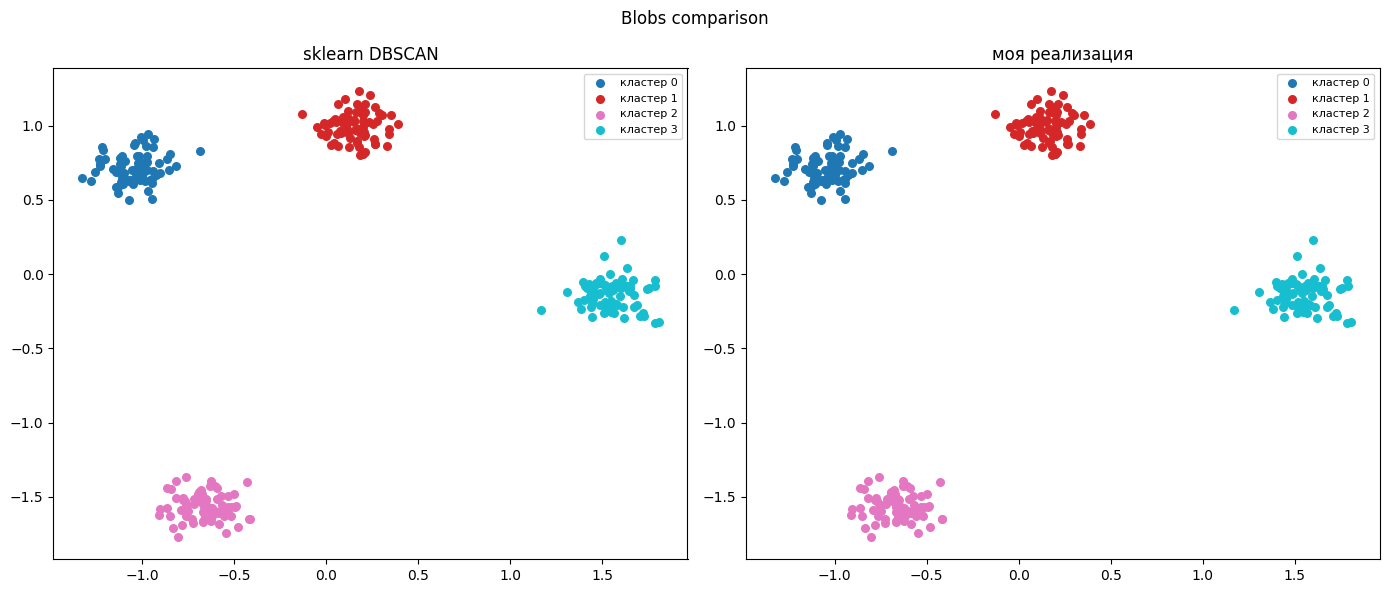

In [29]:
my_labels_blobs, sk_labels_blobs, ari_blobs = compare_dbscan(
    X_blobs, eps=0.3, min_samples=5, dataset_name='Blobs'
)
plot_comparison(X_blobs, my_labels_blobs, sk_labels_blobs, 'Blobs comparison')

=== Moons (eps=0.25, min_samples=5) ===
                      кластеров      шум
sklearn                       2        0
моя реализация                2        0
Adjusted Rand Index (совпадение разбиений): 1.0000  (1.0 = идентично)



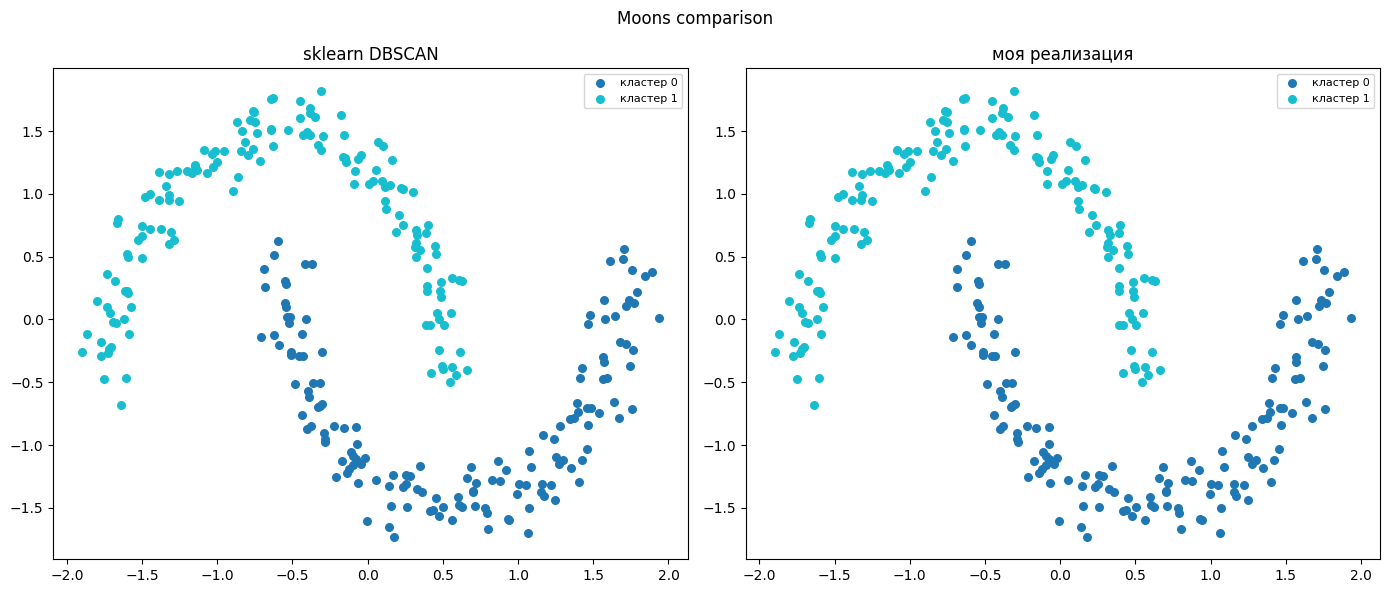

In [30]:
my_labels_moons, sk_labels_moons, ari_moons = compare_dbscan(
    X_moons, eps=0.25, min_samples=5, dataset_name='Moons'
)
plot_comparison(X_moons, my_labels_moons, sk_labels_moons, 'Moons comparison')

=== Circles + noise (eps=0.2, min_samples=5) ===
                      кластеров      шум
sklearn                      14       78
моя реализация               14       78
Adjusted Rand Index (совпадение разбиений): 1.0000  (1.0 = идентично)



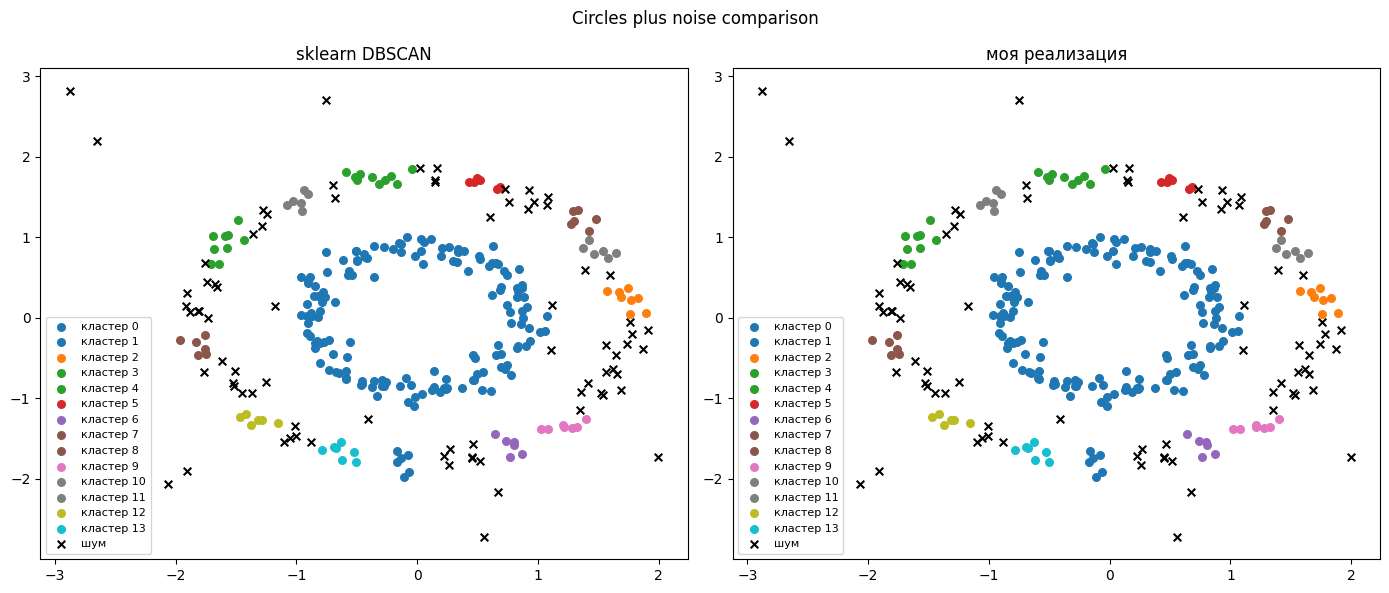

In [31]:
my_labels_circles, sk_labels_circles, ari_circles = compare_dbscan(
    X_circles_noisy, eps=0.2, min_samples=5, dataset_name='Circles + noise'
)
plot_comparison(X_circles_noisy, my_labels_circles, sk_labels_circles, 'Circles plus noise comparison')

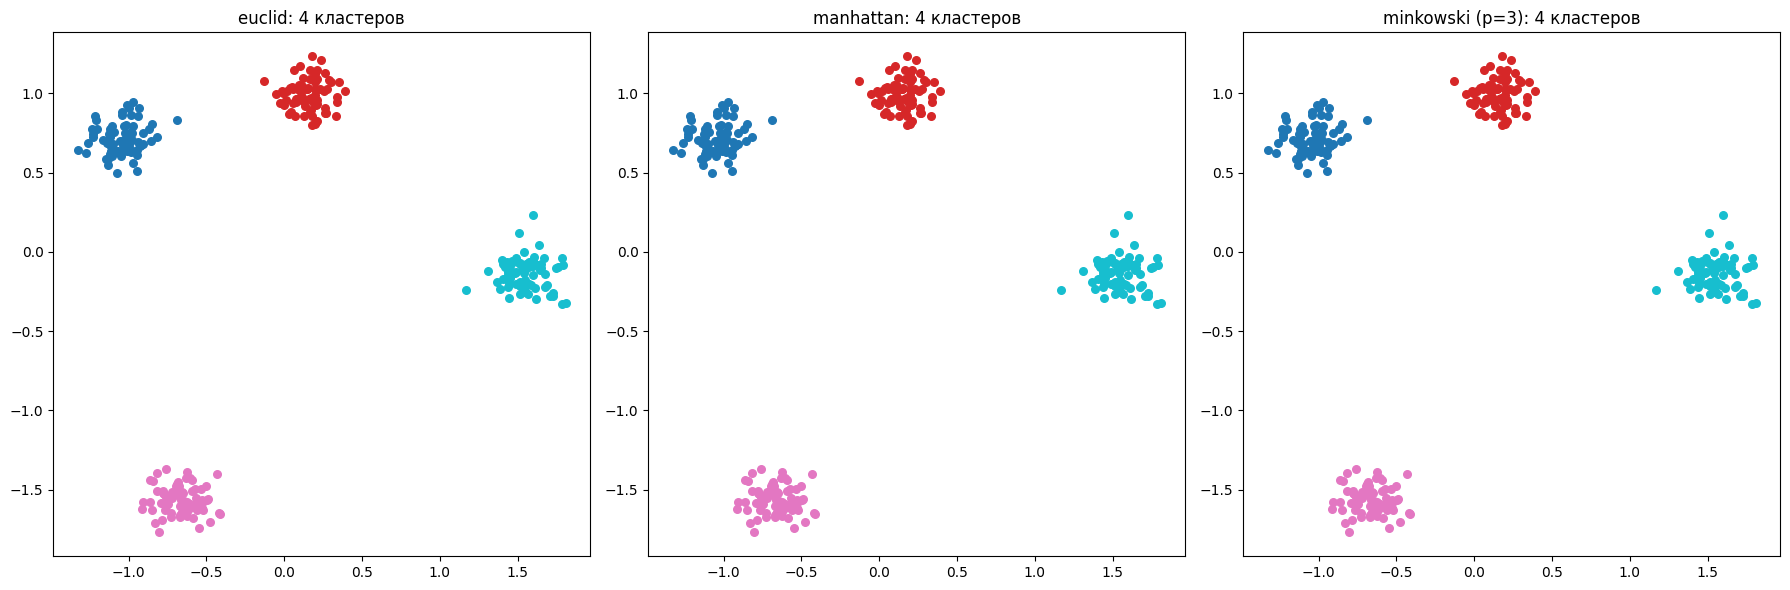

In [32]:
distance_funcs_to_test = [
    ('euclid', dict(distance_func='euclid')),
    ('manhattan', dict(distance_func='manhattan')),
    ('minkowski (p=3)', dict(distance_func='minkowski', p=3)),
]

fig, axes = plt.subplots(1, len(distance_funcs_to_test), figsize=(6 * len(distance_funcs_to_test), 6))

for ax, (name, kwargs) in zip(axes, distance_funcs_to_test):
    model = DBSCAN(eps=0.3, min_samples=5, **kwargs)
    labels = model.fit_predict(X_blobs)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    unique_labels = set(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
    for label, color in zip(unique_labels, colors):
        mask = labels == label
        if label == -1:
            ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1], c='black', marker='x', s=30)
        else:
            ax.scatter(X_blobs[mask, 0], X_blobs[mask, 1], c=[color], s=30)
    ax.set_title(f'{name}: {n_clusters} кластеров')

plt.tight_layout()
plt.savefig('distance_functions_comparison.png', dpi=100)
plt.show()

In [33]:
model_all_noise = DBSCAN(eps=0.01, min_samples=5, distance_func='euclid')
labels_all_noise = model_all_noise.fit_predict(X_blobs)
print(f"eps=0.01 (очень маленький): кластеров={model_all_noise.n_clusters_}, "
      f"шум={model_all_noise.n_noise_} из {X_blobs.shape[0]}")

eps=0.01 (очень маленький): кластеров=0, шум=300 из 300


In [34]:
model_one_cluster = DBSCAN(eps=100, min_samples=5, distance_func='euclid')
labels_one_cluster = model_one_cluster.fit_predict(X_blobs)
print(f"eps=100 (очень большой): кластеров={model_one_cluster.n_clusters_}, "
      f"шум={model_one_cluster.n_noise_} (ожидается 1 кластер, 0 шума)")

eps=100 (очень большой): кластеров=1, шум=0 (ожидается 1 кластер, 0 шума)


In [35]:
model_ms1 = DBSCAN(eps=0.3, min_samples=1, distance_func='euclid')
labels_ms1 = model_ms1.fit_predict(X_blobs)
print(f"min_samples=1: кластеров={model_ms1.n_clusters_}, шум={model_ms1.n_noise_}")

min_samples=1: кластеров=4, шум=0


      dataset  ARI
        Blobs  1.0
        Moons  1.0
Circles+noise  1.0


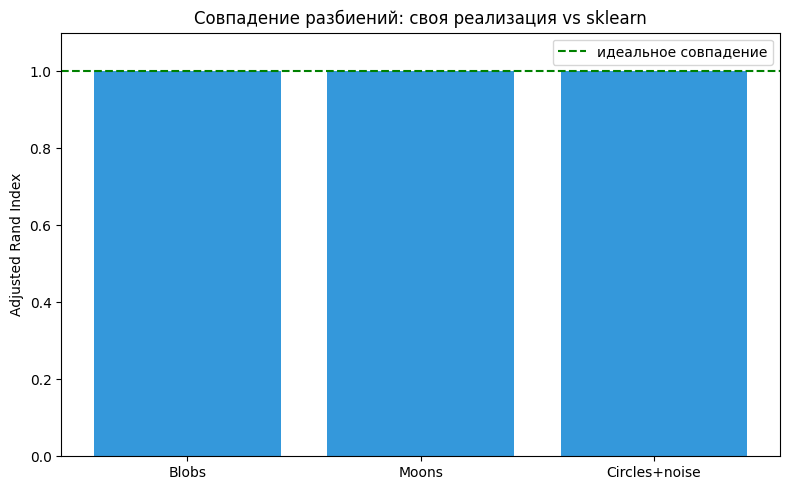

In [36]:
summary = pd.DataFrame([
    {'dataset': 'Blobs', 'ARI': ari_blobs},
    {'dataset': 'Moons', 'ARI': ari_moons},
    {'dataset': 'Circles+noise', 'ARI': ari_circles},
])
print(summary.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(summary['dataset'], summary['ARI'], color='#3498db')
plt.axhline(y=1.0, color='green', linestyle='--', label='идеальное совпадение')
plt.ylabel('Adjusted Rand Index')
plt.title('Совпадение разбиений: своя реализация vs sklearn')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.savefig('ari_summary.png', dpi=100)
plt.show()